<a href="https://colab.research.google.com/github/ivan-block/Traffic-signs-classification/blob/main/up2561204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential, Model
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras import layers
from keras.layers import (
    Dense, Dropout, Flatten, Conv2D,
    MaxPooling2D, BatchNormalization,
    Input, GlobalAveragePooling2D
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


np.random.seed(42)
tf.random.set_seed(42)

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
!unzip -o gdrive/MyDrive/traffic.zip -d /content/

Mounted at /content/gdrive
Archive:  gdrive/MyDrive/traffic.zip
   creating: /content/traffic/
   creating: /content/traffic/Red/
  inflating: /content/traffic/Red/000803.jpg  
  inflating: /content/traffic/Red/000806.jpg  
  inflating: /content/traffic/Red/000856.jpg  
  inflating: /content/traffic/Red/000865.jpg  
  inflating: /content/traffic/Red/000867.jpg  
  inflating: /content/traffic/Red/000873.jpg  
  inflating: /content/traffic/Red/000878.jpg  
  inflating: /content/traffic/Red/000879.jpg  
  inflating: /content/traffic/Red/000882.jpg  
  inflating: /content/traffic/Red/000892.jpg  
  inflating: /content/traffic/Red/000896.jpg  
  inflating: /content/traffic/Red/000903.jpg  
  inflating: /content/traffic/Red/000905.jpg  
  inflating: /content/traffic/Red/000911.jpg  
  inflating: /content/traffic/Red/000916.jpg  
  inflating: /content/traffic/Red/000920.jpg  
  inflating: /content/traffic/Red/000928.jpg  
  inflating: /content/traffic/Red/000951.jpg  
  inflating: /content/tr

In [3]:
X = []
Z = []
IMG_SIZE  = 64
GREEN_DIR = '/content/traffic/Green'
RED_DIR   = '/content/traffic/Red'

def make_train_data(traffic_sign, DIR):
    loaded = 0
    for fname in os.listdir(DIR):
        path = os.path.join(DIR, fname)
        img  = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(np.array(img))
        Z.append(traffic_sign)
        loaded += 1
    print(f'Loaded {loaded:4d} images  —  class: "{traffic_sign}"')

make_train_data('Green', GREEN_DIR)
make_train_data('Red',   RED_DIR)
print(f'\nTotal: {len(X)} images')

Loaded  100 images  —  class: "Green"
Loaded  100 images  —  class: "Red"

Total: 200 images


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

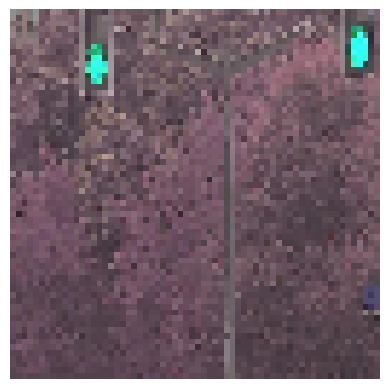

In [4]:
plt.imshow(X[1][:,:,::-1])
plt.axis('off')

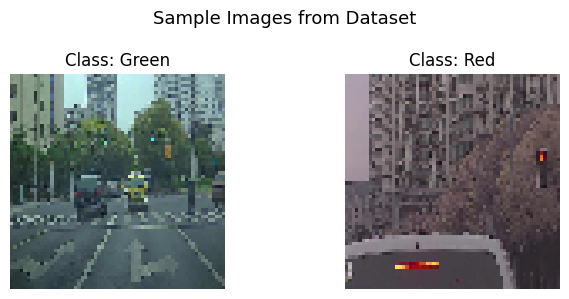

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, idx, label in zip(axes,
                          [Z.index('Green'), Z.index('Red')],
                          ['Green', 'Red']):
    ax.imshow(cv2.cvtColor(X[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f'Class: {label}', fontsize=12)
    ax.axis('off')
plt.suptitle('Sample Images from Dataset', fontsize=13)
plt.tight_layout()
plt.show()

### Label Encoding and Normalisation

In [6]:
le = LabelEncoder()
Y  = le.fit_transform(Z)
Y  = to_categorical(Y,2)
X  = np.array(X, dtype='float32') / 255.0

print('X shape:', X.shape, ' | Y shape:', Y.shape)

X shape: (200, 64, 64, 3)  | Y shape: (200, 2)


In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)
print(f'Training samples : {x_train.shape[0]}')
print(f'Test samples     : {x_test.shape[0]}')
print(f'Image shape      : {x_train.shape[1:]}')

Training samples : 160
Test samples     : 40
Image shape      : (64, 64, 3)


In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.1),
], name='augmentation')

BATCH_SIZE = 32

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), seed=42)
    .batch(BATCH_SIZE)
    .map(lambda imgs, labels:
         (data_augmentation(imgs, training=True), labels),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [9]:
def build_cnn(input_shape=(64, 64, 3)):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ], name='traffic_cnn')
    return model

model = build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3))
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "traffic_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,190,178 (4.54 MB)

 Trainable params: 1,189,282 (4.54 MB)

 Non-trainable params: 896 (3.50 KB)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-7, verbose=1)
]

History = model.fit(
    train_ds,
    epochs=60,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 763ms/step - accuracy: 0.4875 - loss: 1.4763 - val_accuracy: 0.5000 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.4812 - loss: 1.0315 - val_accuracy: 0.5000 - val_loss: 0.6961 - learning_rate: 0.0010
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4313 - loss: 1.0150 - val_accuracy: 0.5000 - val_loss: 0.7188 - learning_rate: 0.0010
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4313 - loss: 1.0369 - val_accuracy: 0.5000 - val_loss: 0.7766 - learning_rate: 0.0010
Epoch 5/60
3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5243 - loss: 0.8160 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.9007 - val_accuracy: 0.5000 - val_loss: 0.7949 - learning_rate: 0.0010
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4688 - loss: 0.9691 - val_accuracy: 0.500

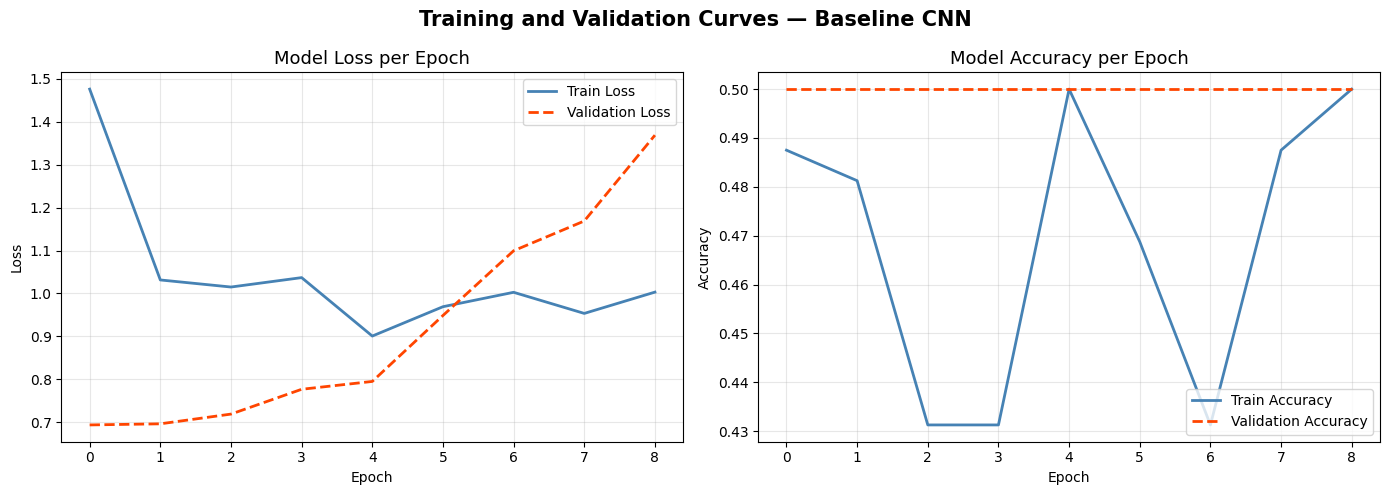

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(History.history['loss'],
             color='steelblue', linewidth=2, label='Train Loss')
axes[0].plot(History.history['val_loss'],
             color='orangered', linewidth=2, linestyle='--', label='Validation Loss')
axes[0].set_title('Model Loss per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(History.history['accuracy'],
             color='steelblue', linewidth=2, label='Train Accuracy')
axes[1].plot(History.history['val_accuracy'],
             color='orangered', linewidth=2, linestyle='--', label='Validation Accuracy')
axes[1].set_title('Model Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training and Validation Curves — Baseline CNN', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Evaluate on TRAINING set and TEST set to measure overfitting gap
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
cnn_loss,   cnn_acc   = model.evaluate(val_ds,   verbose=0)

print(f'  Baseline CNN  |  Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%')
print(f'  Baseline CNN  |  Test  Loss: {cnn_loss:.4f}  Test  Acc: {cnn_acc*100:.2f}%')
gap = (train_acc - cnn_acc) * 100
print(f'  Overfitting gap (train - test acc): {gap:+.2f}%')


  Baseline CNN  |  Train Loss: 0.8472  Train Acc: 46.25%
  Baseline CNN  |  Test  Loss: 0.6935  Test  Acc: 50.00%
  Overfitting gap (train - test acc): -3.75%


### Baseline CNN Predictions

#    True Label   Predicted      Confidence   Correct?
------------------------------------------------------
1     Green        Red                51.3%        No
2     Red          Red                51.2%       Yes
3     Green        Red                51.0%        No
4     Red          Red                50.7%       Yes
5     Red          Red                51.1%       Yes


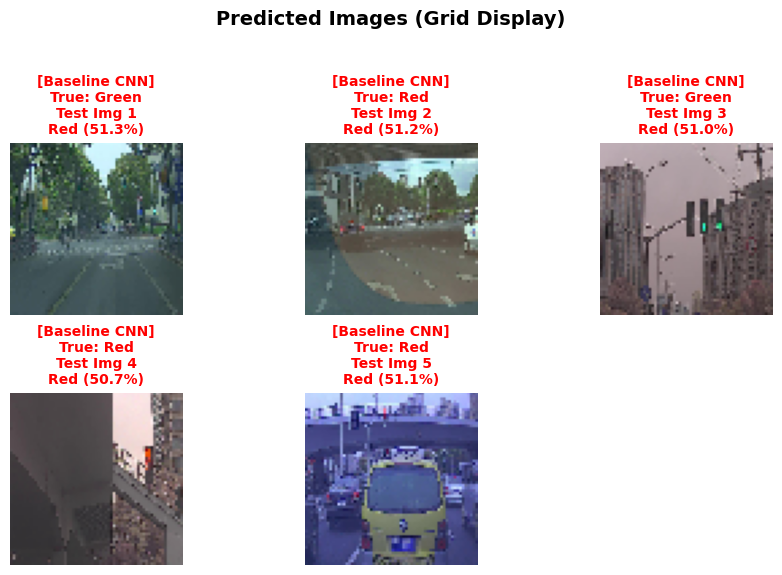

In [16]:
import numpy as np

predictions_for_grid_cnn = []

# Define class_names and test_indices here for use in this cell
class_names = le.classes_
test_indices = np.random.choice(len(x_test), size=5, replace=False)

print(f'{"#":<4} {"True Label":<12} {"Predicted":<12} {"Confidence":>12} {"Correct?":>10}')
print('-' * 54)

for i, idx in enumerate(test_indices):
    img_cnn    = x_test[idx]
    true_label = class_names[np.argmax(y_test[idx])]

    # Use get_single_image_prediction with the baseline CNN model and IMG_SIZE. Pass BGR image directly.
    img_rgb_pred, pred_label, confidence = get_single_image_prediction((img_cnn * 255).astype(np.uint8), chosen_model=model, chosen_size=IMG_SIZE)
    correct    = pred_label == true_label

    predictions_for_grid_cnn.append((img_rgb_pred, f'True: {true_label}\nTest Img {i+1}', pred_label, confidence))
    print(f'{i+1:<5} {true_label:<12} {pred_label:<12} {confidence:>10.1f}%  {"Yes" if correct else "No":>8}')

plot_predictions_grid(predictions_for_grid_cnn, model_label='Baseline CNN', max_cols=3)

In [17]:
def get_single_image_prediction(img_bgr, chosen_model=None, chosen_size=IMG_SIZE):
    if chosen_model is None:
        chosen_model = model

    img_r  = cv2.resize(img_bgr, (chosen_size, chosen_size))
    norm   = img_r.astype('float32') / 255.0
    probs  = chosen_model.predict(norm.reshape(1, chosen_size, chosen_size, 3), verbose=0)[0]
    pred   = le.classes_[np.argmax(probs)]
    conf   = np.max(probs) * 100
    rgb    = cv2.cvtColor(img_r, cv2.COLOR_BGR2RGB)

    return rgb, pred, conf

def plot_predictions_grid(predictions, model_label='CNN', max_cols=3):
    """Plots a list of images with their predictions in a grid layout."""
    num_images = len(predictions)
    if num_images == 0:
        print("No images to display.")
        return

    max_display_count = max_cols * max_cols
    display_predictions = predictions[:max_display_count]

    nrows = (len(display_predictions) + max_cols - 1) // max_cols
    ncols = min(len(display_predictions), max_cols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(max_cols * 3, nrows * 3))
    axes = axes.flatten() if num_images > 1 else [axes]

    for i, (rgb_img, filename, pred, conf) in enumerate(display_predictions):
        ax = axes[i]
        ax.imshow(rgb_img)
        ax.set_title(f'[{model_label}]\n{os.path.basename(filename)}\n{pred} ({conf:.1f}%)',
                     fontsize=10, fontweight='bold',
                     color='green' if pred == 'Green' else 'red')
        ax.axis('off')

    for j in range(len(display_predictions), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Predicted Images (Grid Display)', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [18]:
from keras.applications import MobileNetV2

IMG_TL = 96

def resize_set(X_in, size):
    return np.array([
        cv2.resize((img * 255).astype(np.uint8), (size, size)).astype('float32') / 255.0
        for img in X_in
    ])

print('Resizing for MobileNetV2...')
x_train_tl = resize_set(x_train, IMG_TL)
x_test_tl  = resize_set(x_test,  IMG_TL)
print(f'x_train_tl shape: {x_train_tl.shape}')

base_mv2 = MobileNetV2(input_shape=(IMG_TL, IMG_TL, 3),
                        include_top=False, weights='imagenet')
base_mv2.trainable = False

inp  = Input(shape=(IMG_TL, IMG_TL, 3))
x    = base_mv2(inp, training=False)
x    = GlobalAveragePooling2D()(x)
x    = Dense(128, activation='relu')(x)
x    = BatchNormalization()(x)
x    = Dropout(0.4)(x)
out  = Dense(2, activation='softmax')(x)

mv2_model = Model(inp, out, name='MobileNetv2')
mv2_model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
mv2_model.summary()

Resizing for MobileNetV2...
x_train_tl shape: (160, 96, 96, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,722 (9.24 MB)

 Trainable params: 164,482 (642.51 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [19]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Phase 1 — train head only
print('Phase 1: training head (MobileNetV2 backbone frozen)...')
mv2_h1 = mv2_model.fit(
    x_train_tl, y_train,
    epochs=20, batch_size=32,
    validation_split=0.1,
    callbacks=[es], verbose=1
)

# Phase 2 — fine-tune top 20 backbone layers
print('\nPhase 2: fine-tuning top 20 MobileNetV2 layers...')
base_mv2.trainable = True
for layer in base_mv2.layers[:-20]:
    layer.trainable = False

mv2_model.compile(optimizer=Adam(1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

mv2_h2 = mv2_model.fit(
    x_train_tl, y_train,
    epochs=20, batch_size=32,
    validation_split=0.1,
    callbacks=[es], verbose=1
)

_, mv2_acc = mv2_model.evaluate(x_test_tl, y_test, verbose=0)
print(f'\nBaseline CNN Test Accuracy  : {cnn_acc * 100:.2f}%')
print(f'MobileNetV2 Test Accuracy   : {mv2_acc * 100:.2f}%')
print(f'Improvement                 : {(mv2_acc - cnn_acc) * 100:+.2f}%')
# Evaluate MobileNetV2: training set and test set
mv2_train_loss, mv2_train_acc = mv2_model.evaluate(x_train_tl, y_train, verbose=0)
mv2_loss,       mv2_acc       = mv2_model.evaluate(x_test_tl,  y_test,  verbose=0)
print('=' * 60)
print(f'  MobileNetV2  |  Train Loss: {mv2_train_loss:.4f}  Train Acc: {mv2_train_acc*100:.2f}%')
print(f'  MobileNetV2  |  Test  Loss: {mv2_loss:.4f}  Test  Acc: {mv2_acc*100:.2f}%')
print(f'  Overfitting gap: {(mv2_train_acc - mv2_acc)*100:+.2f}%')
print('=' * 60)
print(f'Improvement over CNN: {(mv2_acc - cnn_acc)*100:+.2f}%')


Phase 1: training head (MobileNetV2 backbone frozen)...
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.5486 - loss: 0.9332 - val_accuracy: 0.6875 - val_loss: 0.8195
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8472 - loss: 0.3523 - val_accuracy: 0.6250 - val_loss: 0.7190
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8819 - loss: 0.2638 - val_accuracy: 0.6250 - val_loss: 0.7127
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9583 - loss: 0.1554 - val_accuracy: 0.6250 - val_loss: 0.7340
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9583 - loss: 0.1190 - val_accuracy: 0.6250 - val_loss: 0.7534
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9722 - loss: 0.1021 - val_accuracy: 0.6250 - val_loss: 0.7335
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9653 - loss: 0.0921 - val_accuracy: 0.6250 - val_loss: 0.7110
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - 

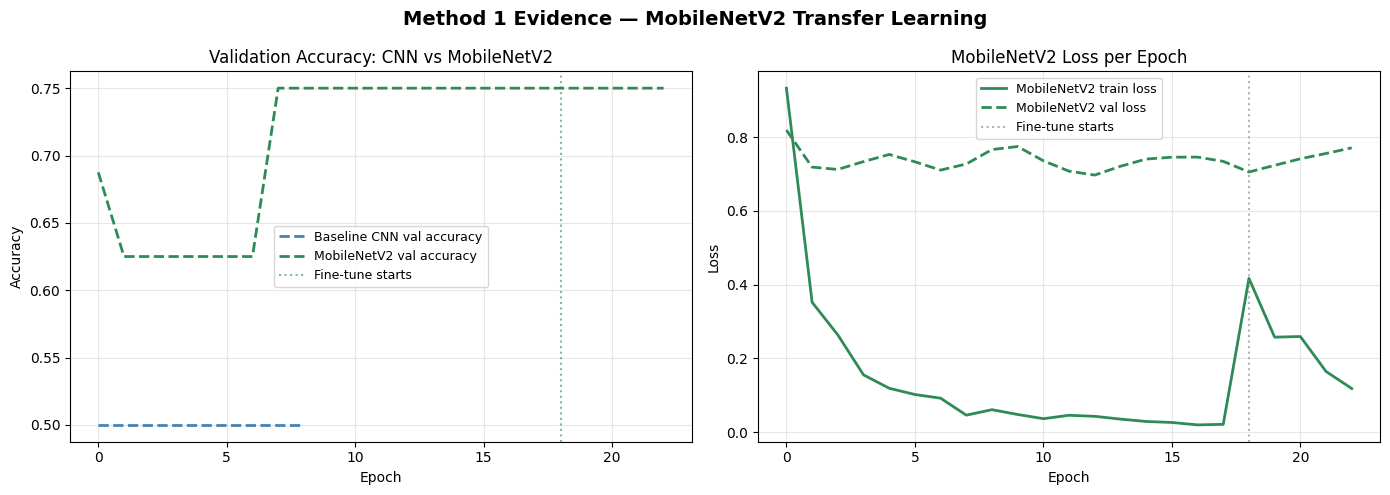

In [20]:
mv2_train_acc = mv2_h1.history['accuracy']     + mv2_h2.history['accuracy']
mv2_val_acc   = mv2_h1.history['val_accuracy'] + mv2_h2.history['val_accuracy']
mv2_train_loss= mv2_h1.history['loss']         + mv2_h2.history['loss']
mv2_val_loss  = mv2_h1.history['val_loss']     + mv2_h2.history['val_loss']
phase2_start  = len(mv2_h1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(History.history['val_accuracy'],
             color='steelblue', lw=2, ls='--', label='Baseline CNN val accuracy')
axes[0].plot(mv2_val_acc,
             color='seagreen', lw=2, ls='--', label='MobileNetV2 val accuracy')
axes[0].axvline(phase2_start, color='seagreen', ls=':', alpha=0.6, label='Fine-tune starts')
axes[0].set_title('Validation Accuracy: CNN vs MobileNetV2', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# MobileNetV2 loss
axes[1].plot(mv2_train_loss, color='seagreen', lw=2, label='MobileNetV2 train loss')
axes[1].plot(mv2_val_loss,   color='seagreen', lw=2, ls='--', label='MobileNetV2 val loss')
axes[1].axvline(phase2_start, color='grey', ls=':', alpha=0.6, label='Fine-tune starts')
axes[1].set_title('MobileNetV2 Loss per Epoch', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Method 1 Evidence — MobileNetV2 Transfer Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
from keras.applications import VGG16

IMG_VGG = 96
x_train_vgg = x_train_tl
x_test_vgg  = x_test_tl

base_vgg = VGG16(input_shape=(IMG_VGG, IMG_VGG, 3),
                 include_top=False, weights='imagenet')
base_vgg.trainable = False

inp  = Input(shape=(IMG_VGG, IMG_VGG, 3))
x    = base_vgg(inp, training=False)
x    = GlobalAveragePooling2D()(x)
x    = Dense(128, activation='relu')(x)
x    = BatchNormalization()(x)
x    = Dropout(0.4)(x)
out  = Dense(2, activation='softmax')(x)

vgg_model = Model(inp, out, name='VGG16')
vgg_model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,122 (56.39 MB)

 Trainable params: 66,178 (258.51 KB)

 Non-trainable params: 14,714,944 (56.13 MB)

In [22]:
es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print('Phase 1: training head (VGG16 backbone frozen)...')
vgg_h1 = vgg_model.fit(
    x_train_vgg, y_train,
    epochs=20, batch_size=32,
    validation_split=0.1,
    callbacks=[es2], verbose=1
)

print('\nPhase 2: fine-tuning VGG16 block5 (last conv block)...')
base_vgg.trainable = True

set_trainable = False
for layer in base_vgg.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    layer.trainable = set_trainable

vgg_model.compile(optimizer=Adam(1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

vgg_h2 = vgg_model.fit(
    x_train_vgg, y_train,
    epochs=20, batch_size=32,
    validation_split=0.1,
    callbacks=[es2], verbose=1
)

_, vgg_acc = vgg_model.evaluate(x_test_vgg, y_test, verbose=0)
print(f'\nBaseline CNN Test Accuracy : {cnn_acc * 100:.2f}%')
print(f'MobileNetV2 Test Accuracy  : {mv2_acc * 100:.2f}%')
print(f'VGG16 Test Accuracy        : {vgg_acc * 100:.2f}%')

vgg_train_loss, vgg_train_acc = vgg_model.evaluate(x_train_vgg, y_train, verbose=0)
vgg_loss,       vgg_acc       = vgg_model.evaluate(x_test_vgg,  y_test,  verbose=0)
print('=' * 60)
print(f'  VGG16  |  Train Loss: {vgg_train_loss:.4f}  Train Acc: {vgg_train_acc*100:.2f}%')
print(f'  VGG16  |  Test  Loss: {vgg_loss:.4f}  Test  Acc: {vgg_acc*100:.2f}%')
print(f'  Overfitting gap: {(vgg_train_acc - vgg_acc)*100:+.2f}%')
print('=' * 60)
print(f'Improvement over CNN: {(vgg_acc - cnn_acc)*100:+.2f}%')


Phase 1: training head (VGG16 backbone frozen)...
Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4722 - loss: 1.0567 - val_accuracy: 0.7500 - val_loss: 0.6027
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7083 - loss: 0.6070 - val_accuracy: 0.8125 - val_loss: 0.6004
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7083 - loss: 0.6481 - val_accuracy: 0.8125 - val_loss: 0.5944
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7431 - loss: 0.4966 - val_accuracy: 0.7500 - val_loss: 0.5921
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7778 - loss: 0.4807 - val_accuracy: 0.7500 - val_loss: 0.5949
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8264 - loss: 0.4140 - val_accuracy: 0.7500 - val_loss: 0.6014
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7639 - loss: 0.4586 - val_accuracy: 0.6875 - val_loss: 0.6084
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8403 - loss: 

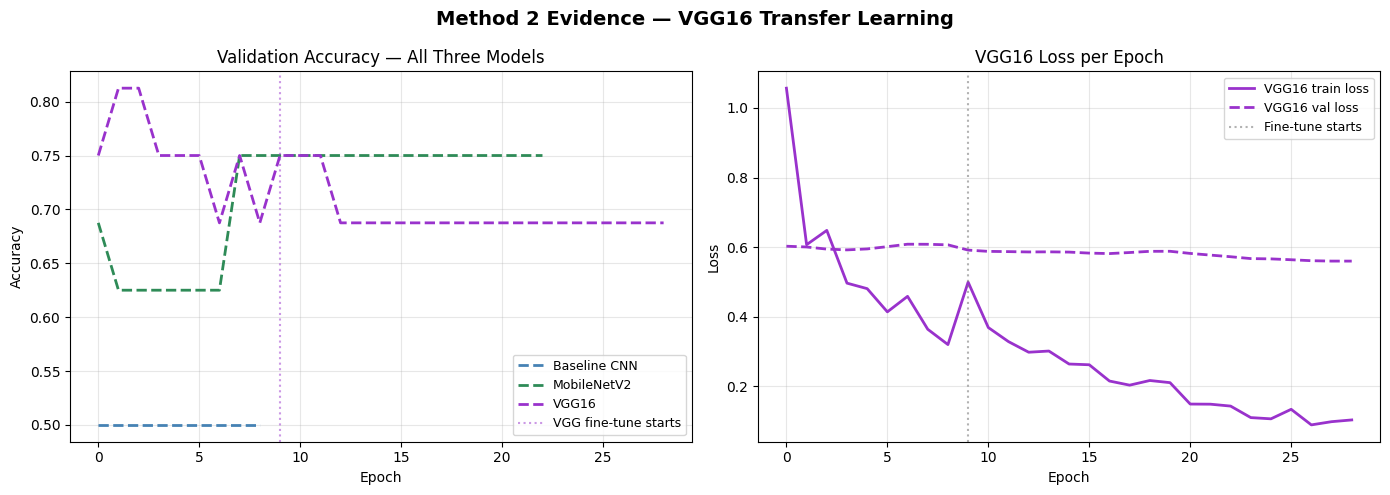

In [23]:
vgg_train_acc = vgg_h1.history['accuracy']     + vgg_h2.history['accuracy']
vgg_val_acc   = vgg_h1.history['val_accuracy'] + vgg_h2.history['val_accuracy']
vgg_train_loss= vgg_h1.history['loss']         + vgg_h2.history['loss']
vgg_val_loss  = vgg_h1.history['val_loss']     + vgg_h2.history['val_loss']
vgg_phase2    = len(vgg_h1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(History.history['val_accuracy'],
             color='steelblue', lw=2, ls='--', label='Baseline CNN')
axes[0].plot(mv2_val_acc,
             color='seagreen',  lw=2, ls='--', label='MobileNetV2')
axes[0].plot(vgg_val_acc,
             color='darkorchid',lw=2, ls='--', label='VGG16')
axes[0].axvline(vgg_phase2, color='darkorchid', ls=':', alpha=0.5, label='VGG fine-tune starts')
axes[0].set_title('Validation Accuracy — All Three Models', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# VGG16 loss
axes[1].plot(vgg_train_loss, color='darkorchid', lw=2, label='VGG16 train loss')
axes[1].plot(vgg_val_loss,   color='darkorchid', lw=2, ls='--', label='VGG16 val loss')
axes[1].axvline(vgg_phase2, color='grey', ls=':', alpha=0.6, label='Fine-tune starts')
axes[1].set_title('VGG16 Loss per Epoch', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Method 2 Evidence — VGG16 Transfer Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

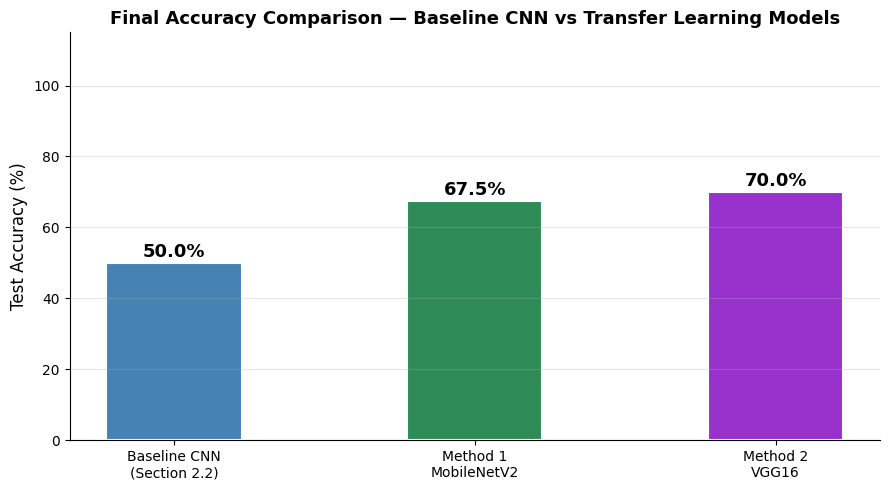

MobileNetV2 improvement over baseline : +17.50%
VGG16 improvement over baseline       : +20.00%


In [24]:
model_names = [
    'Baseline CNN\n(Section 2.2)',
    'Method 1\nMobileNetV2',
    'Method 2\nVGG16'
]
accuracies = [cnn_acc * 100, mv2_acc * 100, vgg_acc * 100]
colours    = ['steelblue', 'seagreen', 'darkorchid']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(model_names, accuracies, color=colours,
              width=0.45, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.1f}%',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )

ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Accuracy Comparison — Baseline CNN vs Transfer Learning Models',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'MobileNetV2 improvement over baseline : {(mv2_acc - cnn_acc)*100:+.2f}%')
print(f'VGG16 improvement over baseline       : {(vgg_acc - cnn_acc)*100:+.2f}%')

In [25]:
!pip install ultralytics -q
from ultralytics import YOLO
import pathlib, shutil, pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [26]:
YOLO_DIR = pathlib.Path('/content/yolo_traffic')
if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)
for split in ['train', 'val']:
    for cls in ['Green', 'Red']:
        (YOLO_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def save_for_yolo(X_split, Y_split, split_name):
    counts = {c: 0 for c in le.classes_}
    for i, (img, loh) in enumerate(zip(X_split, Y_split)):
        cls = le.classes_[np.argmax(loh)]
        cv2.imwrite(str(YOLO_DIR / split_name / cls / f'{i:05d}.jpg'),
                    (img * 255).astype(np.uint8))
        counts[cls] += 1
    print(f'  {split_name}: {counts}')

print('Saving images for YOLO...')
save_for_yolo(x_train, y_train, 'train')
save_for_yolo(x_test,  y_test,  'val')
print(f'Done — {YOLO_DIR}')


Saving images for YOLO...
  train: {np.str_('Green'): 80, np.str_('Red'): 80}
  val: {np.str_('Green'): 20, np.str_('Red'): 20}
Done — /content/yolo_traffic


In [27]:
yolo_model = YOLO('yolov8n-cls.pt')

yolo_results = yolo_model.train(
    data     = str(YOLO_DIR),
    epochs   = 40,
    imgsz    = 64,
    batch    = 32,
    patience = 8,
    lr0      = 1e-3,
    cos_lr   = True,
    augment  = True,
    project  = '/content/yolo_runs',
    name     = 'traffic_cls',
    exist_ok = True,
    verbose  = True
)
print('YOLOv8 training complete.')


Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_traffic, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=8, pe

In [28]:
yolo_val       = yolo_model.val(data=str(YOLO_DIR), split='val',   imgsz=64, batch=32, verbose=False)
yolo_train_val = yolo_model.val(data=str(YOLO_DIR), split='train', imgsz=64, batch=32, verbose=False)
yolo_acc       = yolo_val.top1
yolo_train_acc = yolo_train_val.top1

print(f'  YOLOv8n-cls  |  Train Acc: {yolo_train_acc*100:.2f}%')
print(f'  YOLOv8n-cls  |  Test  Acc: {yolo_acc*100:.2f}%')
print(f'  Overfitting gap: {(yolo_train_acc - yolo_acc)*100:+.2f}%')
print(f'Improvement over CNN: {(yolo_acc - cnn_acc)*100:+.2f}%')


Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/yolo_traffic/train... found 160 images in 2 classes ✅ 
val: /content/yolo_traffic/val... found 40 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 226.7±113.0 MB/s, size: 3.0 KB)
val: Scanning /content/yolo_traffic/val... 40 images, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 11.2Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 2/2 15.4it/s 0.1s
                   all      0.775          1
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/yolo_traffic/train... found 160 images in 2 classes ✅ 
val: /content/yolo_traffic/val... found 40 images in 2 classes ✅ 
test: None...
train: 

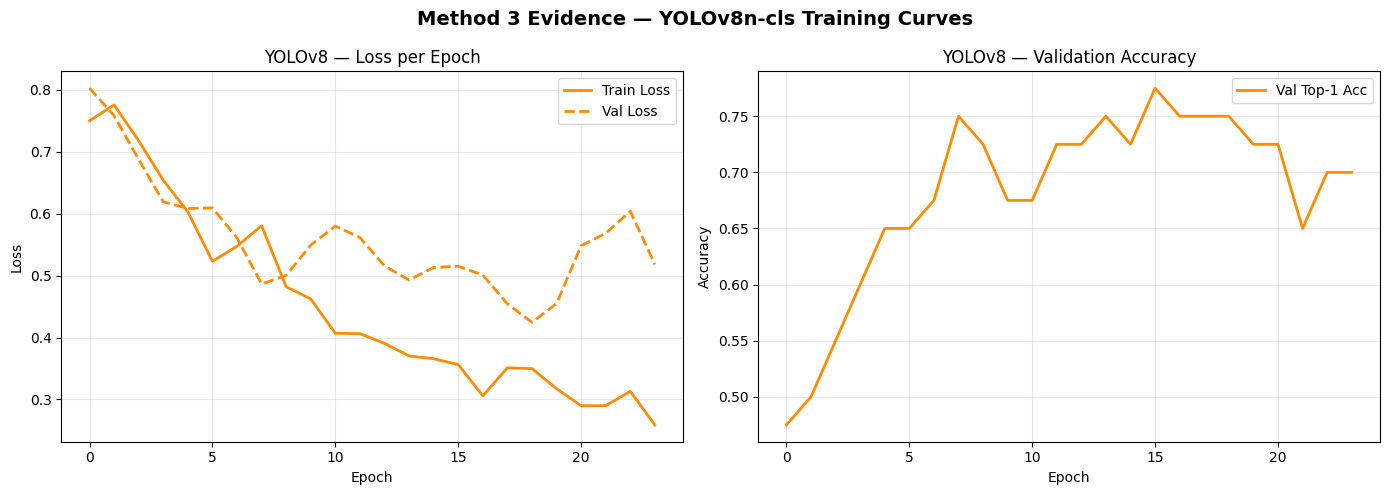

In [29]:
try:
    df = pd.read_csv('/content/yolo_runs/traffic_cls/results.csv')
    df.columns = df.columns.str.strip()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(df['train/loss'], color='darkorange', lw=2, label='Train Loss')
    axes[0].plot(df['val/loss'],   color='darkorange', lw=2, ls='--', label='Val Loss')
    axes[0].set_title('YOLOv8 — Loss per Epoch', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(df['metrics/accuracy_top1'], color='darkorange', lw=2, label='Val Top-1 Acc')
    axes[1].set_title('YOLOv8 — Validation Accuracy', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Method 3 Evidence — YOLOv8n-cls Training Curves', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
except FileNotFoundError:
    print('results.csv not found — check /content/yolo_runs/traffic_cls/')


#    True Label   Predicted      Confidence   Correct?
------------------------------------------------------
1     Red          Red                93.5%       Yes
2     Green        Green              99.7%       Yes
3     Green        Green              92.9%       Yes
4     Red          Red               100.0%       Yes
5     Green        Red                80.6%        No


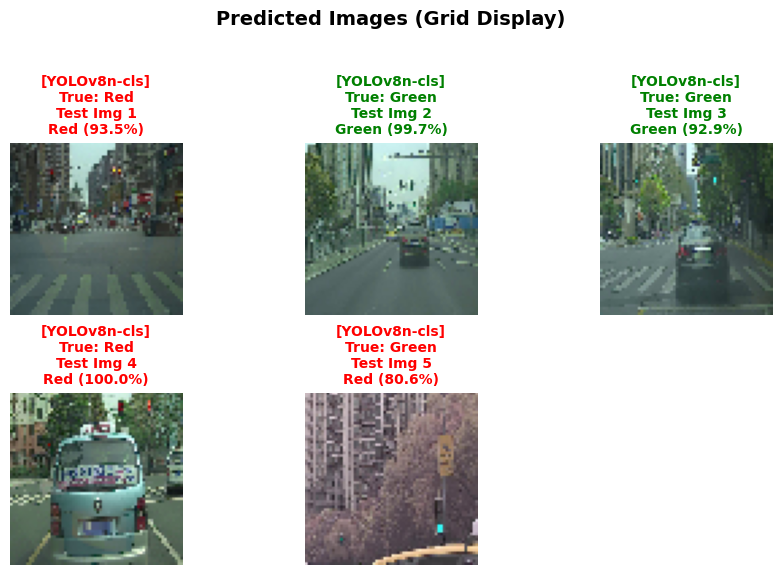

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pathlib

# Define class_names and test_indices, as their previous defining cell was deleted
class_names = le.classes_
test_indices = np.random.choice(len(x_test), size=5, replace=False)

# YOLOv8 predictions on the same 5 test images
tmp = pathlib.Path('/content/yolo_tmp')
tmp.mkdir(exist_ok=True)
tmp_paths = []
for i, idx in enumerate(test_indices):
    p = str(tmp / f'img_{i}.jpg')
    cv2.imwrite(p, (x_test[idx] * 255).astype(np.uint8))
    tmp_paths.append(p)

yolo_preds = yolo_model.predict(tmp_paths, imgsz=64, verbose=False)

predictions_for_grid = []
print(f'{"#":<4} {"True Label":<12} {"Predicted":<12} {"Confidence":>12} {"Correct?":>10}')
print('-' * 54)

for i, (pred, idx) in enumerate(zip(yolo_preds, test_indices)):
    img        = x_test[idx]
    true_label = le.classes_[np.argmax(y_test[idx])]
    pred_label = pred.names[int(pred.probs.top1)]
    confidence = float(pred.probs.top1conf) * 100
    correct    = pred_label == true_label

    img_rgb   = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)


    img_display_for_grid = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    predictions_for_grid.append((img_display_for_grid, f'True: {true_label}\nTest Img {i+1}', pred_label, confidence))
    print(f'{i+1:<5} {true_label:<12} {pred_label:<12} {confidence:>10.1f}%  {"Yes" if correct else "No":>8}')

plot_predictions_grid(predictions_for_grid, model_label='YOLOv8n-cls', max_cols=3)

### MobileNetV2 Predictions

#    True Label   Predicted      Confidence   Correct?
------------------------------------------------------
1     Red          Red                67.9%       Yes
2     Green        Green              72.9%       Yes
3     Green        Green              98.3%       Yes
4     Red          Red                99.3%       Yes
5     Green        Red                81.0%        No


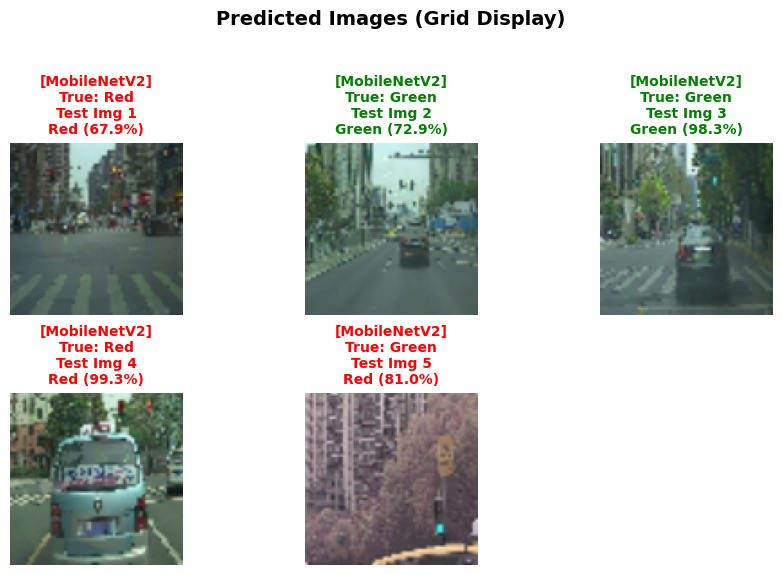

In [33]:
predictions_for_grid_mv2 = []
print(f'{"#":<4} {"True Label":<12} {"Predicted":<12} {"Confidence":>12} {"Correct?":>10}')
print('-' * 54)

for i, idx in enumerate(test_indices):
    img_tl     = x_test_tl[idx]
    true_label = class_names[np.argmax(y_test[idx])]

    # Use get_single_image_prediction with mv2_model and IMG_TL. Pass BGR image directly.
    img_rgb_pred, pred_label, confidence = get_single_image_prediction((img_tl * 255).astype(np.uint8), chosen_model=mv2_model, chosen_size=IMG_TL)
    correct    = pred_label == true_label

    predictions_for_grid_mv2.append((img_rgb_pred, f'True: {true_label}\nTest Img {i+1}', pred_label, confidence))
    print(f'{i+1:<5} {true_label:<12} {pred_label:<12} {confidence:>10.1f}%  {"Yes" if correct else "No":>8}')

plot_predictions_grid(predictions_for_grid_mv2, model_label='MobileNetV2', max_cols=3)

### VGG16 Predictions

#    True Label   Predicted      Confidence   Correct?
------------------------------------------------------
1     Red          Red                55.7%       Yes
2     Green        Green              62.0%       Yes
3     Green        Green              68.2%       Yes
4     Red          Red                67.2%       Yes
5     Green        Green              59.3%       Yes


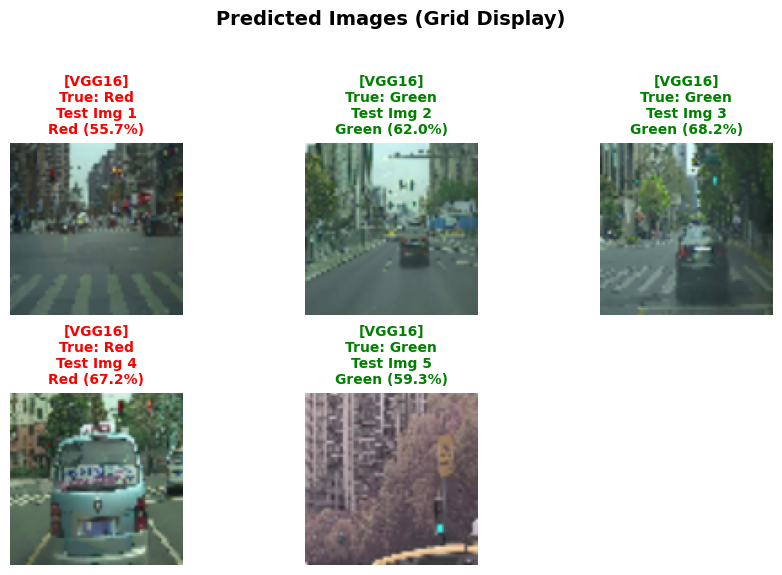

In [34]:
predictions_for_grid_vgg = []
print(f'{"#":<4} {"True Label":<12} {"Predicted":<12} {"Confidence":>12} {"Correct?":>10}')
print('-' * 54)

for i, idx in enumerate(test_indices):
    img_vgg    = x_test_vgg[idx]
    true_label = class_names[np.argmax(y_test[idx])]

    # Use get_single_image_prediction with vgg_model and IMG_VGG. Pass BGR image directly.
    img_rgb_pred, pred_label, confidence = get_single_image_prediction((img_vgg * 255).astype(np.uint8), chosen_model=vgg_model, chosen_size=IMG_VGG)
    correct    = pred_label == true_label

    predictions_for_grid_vgg.append((img_rgb_pred, f'True: {true_label}\nTest Img {i+1}', pred_label, confidence))
    print(f'{i+1:<5} {true_label:<12} {pred_label:<12} {confidence:>10.1f}%  {"Yes" if correct else "No":>8}')

plot_predictions_grid(predictions_for_grid_vgg, model_label='VGG16', max_cols=3)

ALL FOUR MODELS ARE COMPARED WITH BOTH TRAIN AND TEST ACCURACY.
THE OVERFITTING GAP HIGHLIGHTS HOW WELL EACH MODEL GENERALISES.

Model                 Train Acc   Test Acc      Gap  Overfitting?
------------------------------------------------------------------
Baseline CNN             46.25%     50.00%   -3.75%            No
MobileNetV2              96.25%     67.50%  +28.75%           YES
VGG16                    93.12%     70.00%  +23.12%           YES
YOLOv8n-cls              91.25%     77.50%  +13.75%           YES


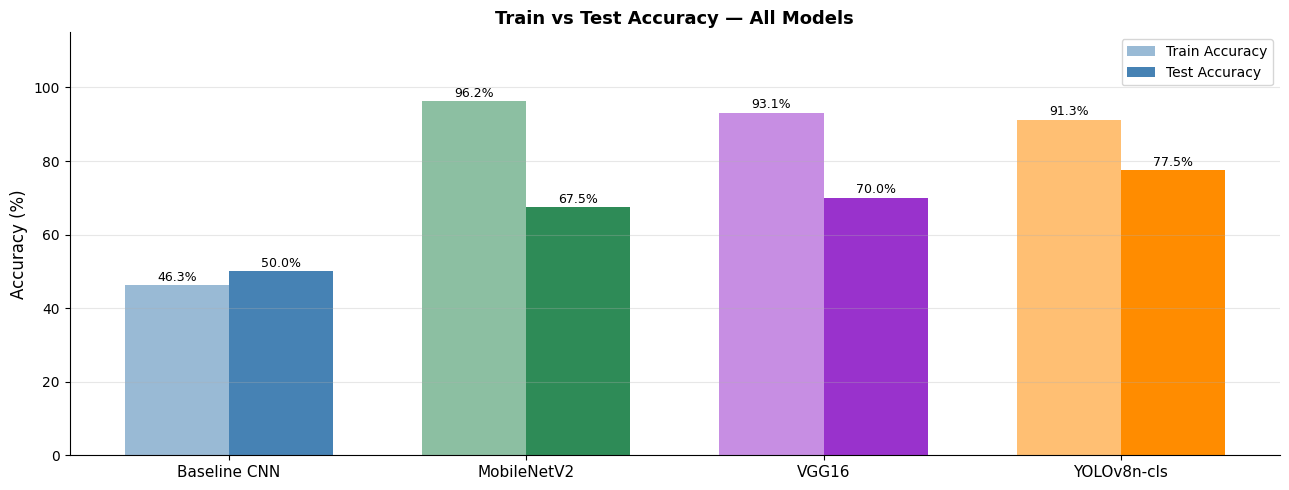

In [35]:
import numpy as np
import matplotlib.pyplot as plt

_, mv2_train_acc = mv2_model.evaluate(x_train_tl, y_train, verbose=0)
_, vgg_train_acc = vgg_model.evaluate(x_train_vgg, y_train, verbose=0)

print(f'{"Model":<20} {"Train Acc":>10} {"Test Acc":>10} {"Gap":>8}  {"Overfitting?":>12}')
print('-' * 66)

all_models = [
    ('Baseline CNN',  train_acc,      cnn_acc),
    ('MobileNetV2',   mv2_train_acc,  mv2_acc),
    ('VGG16',         vgg_train_acc,  vgg_acc),
    ('YOLOv8n-cls',   yolo_train_acc, yolo_acc),
]

for name, tr, te in all_models:
    gap  = (tr - te) * 100
    flag = 'YES' if gap > 10 else ('Mild' if gap > 5 else 'No')
    print(f'{name:<20} {tr*100:>9.2f}% {te*100:>9.2f}% {gap:>+7.2f}%  {flag:>12}')

fig, ax = plt.subplots(figsize=(13, 5))
x      = np.arange(len(all_models))
w      = 0.35
names  = [m[0] for m in all_models]
t_acc  = [m[1] * 100 for m in all_models]
te_acc = [m[2] * 100 for m in all_models]
cols   = ['steelblue', 'seagreen', 'darkorchid', 'darkorange']

b1 = ax.bar(x - w / 2, t_acc,  w, color=cols, alpha=0.55, label='Train Accuracy')
b2 = ax.bar(x + w / 2, te_acc, w, color=cols, alpha=1.00, label='Test Accuracy')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Train vs Test Accuracy — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### USING THE BEST MODEL TO MAKE RANDOM PREDICTIONS ON NEW IMAGES NOT SEEN BEFORE

Found 29 images. Displaying the first 25 predictions in a 5x5 grid...
#    Filename             Predicted      Confidence
--------------------------------------------------
1    1.jpeg               Green              62.0%
2    10.jpeg              Red                99.4%
3    11.jpeg              Red                79.9%
4    12.jpeg              Red                58.5%
5    13.jpeg              Red               100.0%
6    14.jpeg              Red                95.8%
7    15.jpeg              Red                95.5%
8    16.jpeg              Red                96.8%
9    17.jpeg              Red                92.3%
10   18.jpeg              Red                96.6%
11   19.jpeg              Red                99.3%
12   2.jpeg               Green              55.0%
13   20.jpeg              Red                99.1%
14   21.jpeg              Red                92.1%
15   22.jpeg              Red                95.0%
16   23.jpeg              Green              79.3%
17   24.jpe

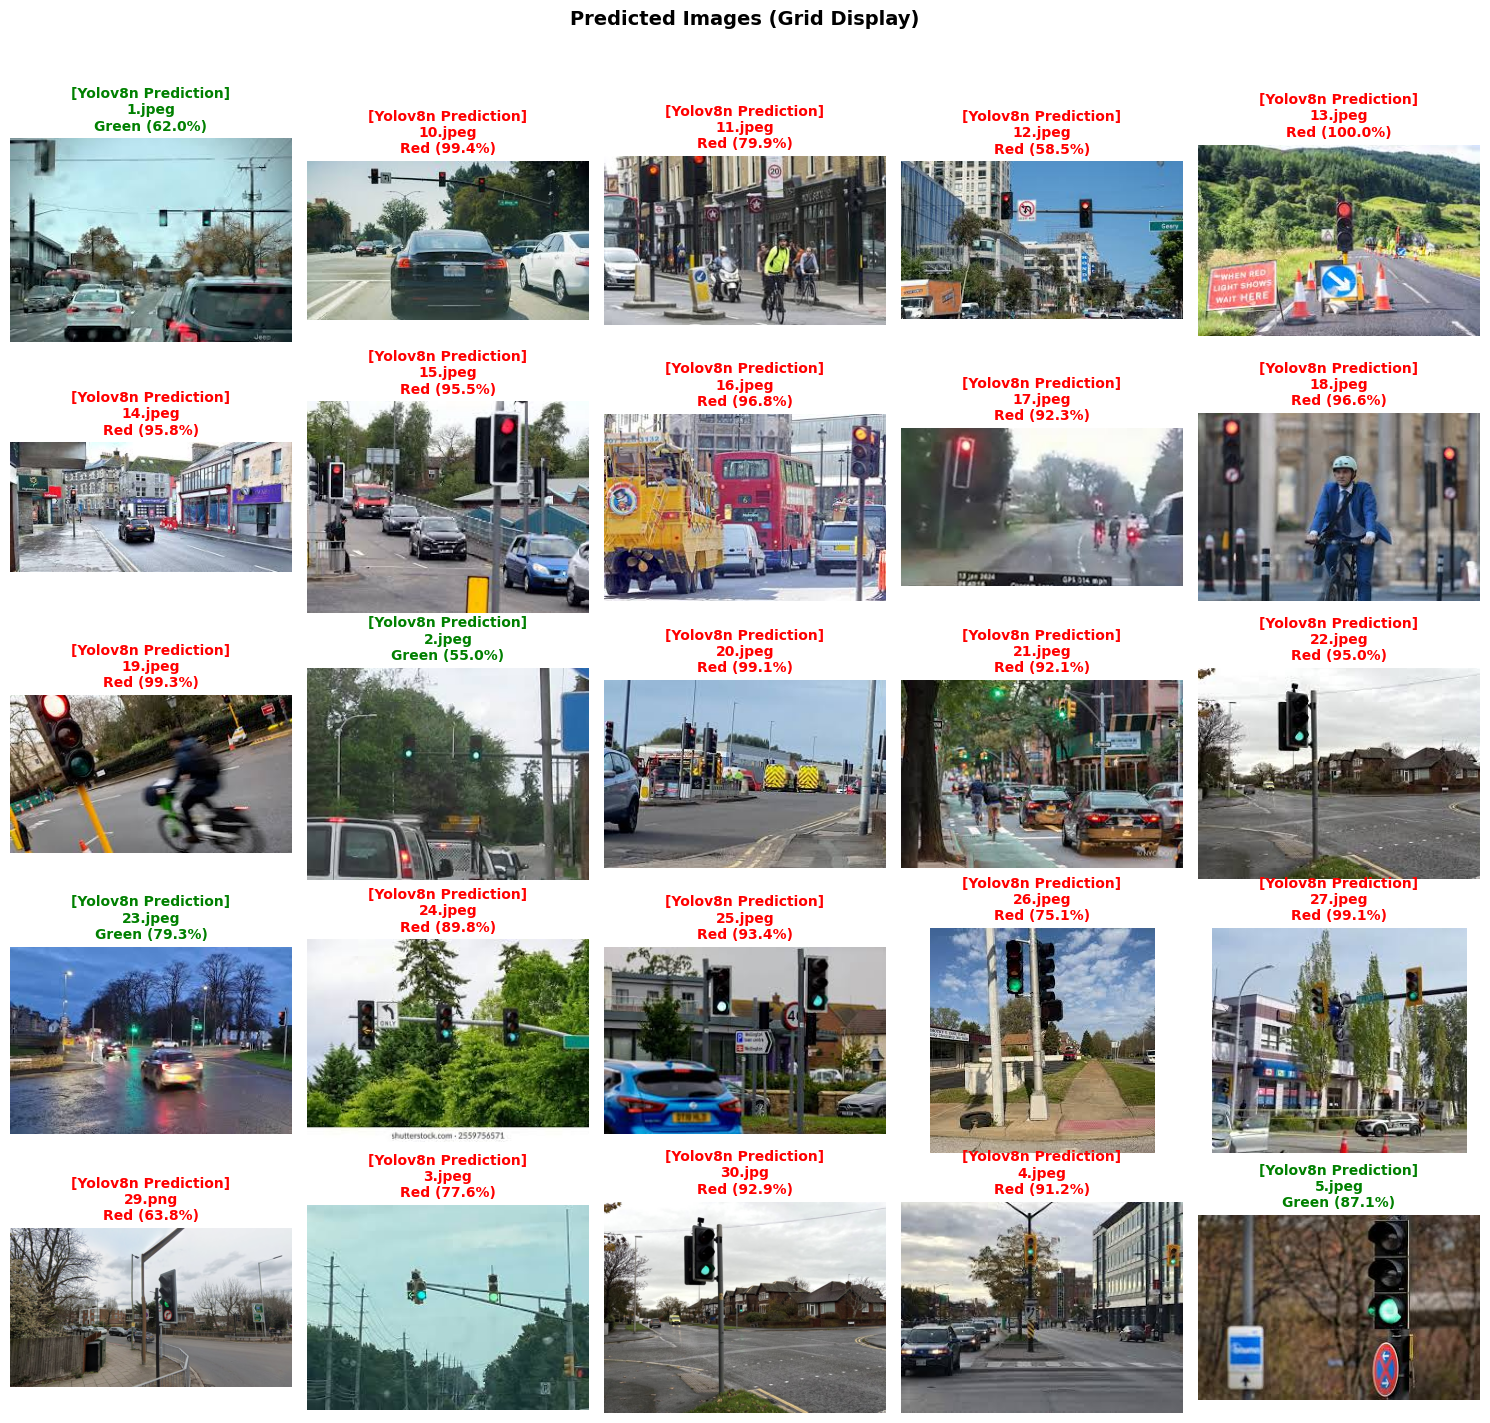


--- Prediction Summary ---
Total images processed: 29
Red predictions: 24 (82.8%)
Green predictions: 5 (17.2%)


In [36]:
import glob as _glob
import os

UPLOAD_DIR = '/content/gdrive/MyDrive/traffic_images/'  # <- change this path

image_paths = (_glob.glob(UPLOAD_DIR + '*.jpg') +
               _glob.glob(UPLOAD_DIR + '*.jpeg') +
               _glob.glob(UPLOAD_DIR + '*.png'))

# Define the maximum number of images to display in the grid
MAX_GRID_DISPLAY = 25 # For a 5x5 grid

if not image_paths:
    print(f'No images found in: {UPLOAD_DIR}')
    print('Check the path or use Method A above.')
elif len(image_paths) > MAX_GRID_DISPLAY:
    print(f'Found {len(image_paths)} images. Displaying the first {MAX_GRID_DISPLAY} predictions in a 5x5 grid...')
else:
    print(f'Found {len(image_paths)} images. Running predictions...')

predictions = []
red_count = 0
green_count = 0

print(f'{'#':<4} {'Filename':<20} {'Predicted':<12} {'Confidence':>12}')
print('-' * 50)
for i, path in enumerate(sorted(image_paths)):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print(f'  Could not read: {path}')
        continue

    # Use the YOLOv8n-cls model for prediction
    # YOLOv8 expects images at imgsz=64 as trained
    results = yolo_model.predict(img_bgr, imgsz=64, verbose=False)[0]
    pred_label = results.names[int(results.probs.top1)]
    confidence = float(results.probs.top1conf) * 100

    # Update counts
    if pred_label == 'Red':
        red_count += 1
    elif pred_label == 'Green':
        green_count += 1

    # Convert image to RGB for display using matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    predictions.append((img_rgb, os.path.basename(path), pred_label, confidence))
    print(f'{i+1:<4} {os.path.basename(path):<20} {pred_label:<12} {confidence:>10.1f}%')

plot_predictions_grid(predictions, model_label='Yolov8n Prediction', max_cols=5)

print('\n--- Prediction Summary ---')
total_predictions = len(predictions)
if total_predictions > 0:
    print(f'Total images processed: {total_predictions}')
    print(f'Red predictions: {red_count} ({red_count / total_predictions:.1%})')
    print(f'Green predictions: {green_count} ({green_count / total_predictions:.1%})')
else:
    print('No predictions were made.')